UPscaledEV Project Main Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Readme:
This code aims at postprocessing the raw session and interval EV data from PowerFlex into files that matches the optimization scripts.
# https://docs.google.com/presentation/d/1JRLf_Qb5xuxuLRH_28HUPq5HQBOIKCjCzQMGXw96MlE/edit?slide=id.g308df064212_0_68#slide=id.g308df064212_0_68

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.

Set working path and import packages

In [3]:
import os
os.chdir('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/EV_data') 
print("Path is:", os.getcwd(), "\n")
import time
from datetime import datetime
import pandas as pd
from pathlib import Path 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ===== EV raw-data configuration =====
# Keep the existing Jan-Jul report in the list. Add newly downloaded PowerFlex
# Aug/Sept/... raw reports here before running this notebook. The notebook will
# concatenate all listed raw reports and overwrite the processed outputs with
# the combined date range.
EV_RAW_SESSION_FILES = [
    "UCSD-All Sites - Portfolio sessions report 01_01_25-07_31_25.csv",
    # "UCSD-All Sites - Portfolio sessions report 08_01_25-08_31_25.csv",
]
EV_RAW_INTERVAL_FILES = [
    "UCSD-All Sites - Portfolio interval report 01_01_25-07_31_25.csv",
    # "UCSD-All Sites - Portfolio interval report 08_01_25-08_31_25.csv",
]

# Use an exclusive upper bound in the filters below. For Jan-Aug, use 2025-09-01.
TheDate_Start = datetime(2025, 1, 1)
TheDate_End = datetime(2025, 9, 1)
# =====================================


Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/EV_data 



1. Add battery size for ML method usage

In [ ]:
# Read raw session EV data from PowerFlex. Multiple files are concatenated.
_session_frames = []
for filename_Input in EV_RAW_SESSION_FILES:
    if not os.path.exists(filename_Input):
        raise FileNotFoundError(f"Missing EV session raw file: {filename_Input}. Update EV_RAW_SESSION_FILES in the config cell.")
    _session_frames.append(pd.read_csv(filename_Input, low_memory=False))
data_Sessions = pd.concat(_session_frames, ignore_index=True).drop_duplicates()
print(f"Loaded {len(EV_RAW_SESSION_FILES)} session raw file(s), rows={len(data_Sessions):,}")
data_CarInfo= pd.read_csv("/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/PowerFlex input for EV statistics to be plugged into master sheet_2024.csv")

# Create extra columns of Car Year, Car Make, and Car Model for Session data
Vehicle_session = data_Sessions['Vehicle']
data_CarInfo['Year'] = data_CarInfo['Year'].astype(str)

Year = []
Make = []
Model = []
BESS = []
case = "new"

# If the Type of data is 'str', its the new data, if its 'int64', its the old data
if case == "new":
    for i in range(len(Vehicle_session)):
        Vehicle_ThisSession = Vehicle_session[i]
        
        if pd.isna(Vehicle_ThisSession):
            Year_ThisSession = 'nan'
            Make_ThisSession = 'nan'
            Model_ThisSession = 'nan'
            BESS_ThisSession = 'nan'
        
        # the 'Vehicle' is NOT 0.000 in the PF session data
        elif len(Vehicle_ThisSession)>6:
            Year_ThisSession = Vehicle_ThisSession.split(' ')[0]
            Make_ThisSession = Vehicle_ThisSession.split(' ')[1]
            Model_ThisSession = Vehicle_ThisSession.split(Year_ThisSession + ' ' +Make_ThisSession+' ')[1]
            BESS_ThisSession = data_CarInfo['Battery (kWh)'][(data_CarInfo['Make']==Make_ThisSession)&\
                                                                (data_CarInfo['Model']==Model_ThisSession)&\
                                                                (data_CarInfo['Year']==Year_ThisSession) ]
           
            if len(pd.Series(BESS_ThisSession))>=1:
               BESS_ThisSession = BESS_ThisSession.iloc[0] 
                
            #if no match, give up one matching the Year, as long as the Make and Model match, asign the BES capacity
            elif len(pd.Series(BESS_ThisSession))==0:
                BESS_ThisSession = data_CarInfo['Battery (kWh)'][(data_CarInfo['Make']==Make_ThisSession)&\
                                                                    (data_CarInfo['Model']==Model_ThisSession)]
            
                if len(pd.Series(BESS_ThisSession))>=1:
                   BESS_ThisSession = BESS_ThisSession.iloc[0]
                   
                #if STILL no match, the BESS capacity is unknown
                elif len(pd.Series(BESS_ThisSession))==0:
                    BESS_ThisSession = 'nan'
        
        # if the 'Vehicle' is 0.000 in the PF session data
        else:
            Year_ThisSession = 'nan'
            Make_ThisSession = 'nan'
            Model_ThisSession = 'nan'
            BESS_ThisSession = 'nan'
            
                    
        Year = Year + [Year_ThisSession]
        Make = Make + [Make_ThisSession]
        Model = Model + [Model_ThisSession]
        BESS = BESS + [BESS_ThisSession]

else:
    for i in range(len(Vehicle_session)):
        Vehicle_ThisSession = Vehicle_session[i]
        data_CarInfo_ThisSession = data_CarInfo[data_CarInfo['Doe Id']==Vehicle_ThisSession]

        if len(data_CarInfo_ThisSession)==0:
            Year = Year + ['nan']
            Make = Make + ['nan']
            Model = Model + ['nan']
            BESS = BESS + ['nan']
            
        else:
            Year = Year + [data_CarInfo_ThisSession['Year'].iloc[0]]
            Make = Make + [data_CarInfo_ThisSession['Make'].iloc[0]]
            Model = Model + [data_CarInfo_ThisSession['Model'].iloc[0]]
            BESS = BESS + [data_CarInfo_ThisSession['Battery (kWh)'].iloc[0]]




data_Sessions['Car Year'] = Year
data_Sessions['Car Make'] = Make
data_Sessions['Car Model'] = Model
data_Sessions['Car Battery'] = BESS


# Write the Session_wCarInfo data to .csv file
data_Sessions.to_csv('UCSD_AllSites_Sessions_wCarInfo.csv', index=False)



2. Merge session data with raw interval data

In [5]:

# Read raw interval EV data from PowerFlex. Multiple files are concatenated.
_interval_frames = []
for filename_Input in EV_RAW_INTERVAL_FILES:
    if not os.path.exists(filename_Input):
        raise FileNotFoundError(f"Missing EV interval raw file: {filename_Input}. Update EV_RAW_INTERVAL_FILES in the config cell.")
    _interval_frames.append(pd.read_csv(filename_Input, low_memory=False))
data_Interval = pd.concat(_interval_frames, ignore_index=True).drop_duplicates()
print(f"Loaded {len(EV_RAW_INTERVAL_FILES)} interval raw file(s), rows={len(data_Interval):,}")

TheDate_Start_str = TheDate_Start.strftime("%Y%m%d")
TheDate_End_str = TheDate_End.strftime("%Y%m%d")
print(f"Processing EV raw data from {TheDate_Start} to {TheDate_End} (exclusive upper-bound intended)")


# Filter the data based on the duration you choose
IntervalStart_datetime = pd.to_datetime(data_Interval['Interval start'])
IntervalEnd_datetime = pd.to_datetime(data_Interval['Interval end'])

SessionStart_datetime = pd.to_datetime(data_Sessions['Session start'])
SessionEnd_datetime = pd.to_datetime(data_Sessions['Session end'])

data_Interval_MySite_MyDates = data_Interval[(TheDate_Start <= IntervalStart_datetime) & (IntervalStart_datetime < TheDate_End) \
                                                & (TheDate_Start <= IntervalEnd_datetime) & (IntervalEnd_datetime < TheDate_End) ]

data_Sessions_MySite_MyDates = data_Sessions[(TheDate_Start <= SessionStart_datetime) & (SessionStart_datetime < TheDate_End) \
                                                & (TheDate_Start <= SessionEnd_datetime) & (SessionEnd_datetime < TheDate_End) ]


# Re asign index to the filtered Interval/Session data

data_Interval_MySite_MyDates_NewInd = data_Interval_MySite_MyDates.copy()
data_Sessions_MySite_MyDates_NewInd = data_Sessions_MySite_MyDates.copy()

# rename column 10-digit session UID in data_sessions:
data_Sessions_MySite_MyDates_NewInd = data_Sessions_MySite_MyDates_NewInd.rename(columns={'10-digit session UID': '10-digit UID'})

UID_list_Interval = data_Interval_MySite_MyDates_NewInd["10-digit UID"].unique()
UID_list_Sessions = data_Sessions_MySite_MyDates_NewInd["10-digit UID"].unique()

ColumnNames_appen = [
    "10-digit UID", "Session start", "Session end", "Session duration (minutes)", "Charging duration (minutes)","Session idle (minutes)", "kWh delivered",\
    "SoC Start","SoC End","User", "Vehicle", "EVSE Status", "Serial #", \
    "Station Name", "Site", 'Car Year', 'Car Make', 'Car Model', 'Car Battery']    
    
data_Sessions_appen = data_Sessions_MySite_MyDates_NewInd.filter(ColumnNames_appen)

# Merge the Sessions and the Interval data by "10-digit UID"
data_Interval_MySite_aux = []
UID_missing = list()

import pandas as pd

data_Interval_MySite_aux = pd.merge(
    data_Interval_MySite_MyDates_NewInd,
    data_Sessions_appen,
    on="10-digit UID",
    how="inner"
)

# UIDs that are missing from sessions
UID_missing = set(UID_list_Interval) - set(data_Sessions_appen["10-digit UID"])

print("Missing UIDs ratio: ", len(UID_missing)/len(UID_list_Interval) * 100, "%")

data_Interval_MySite_aux.to_csv("UCSD_AllSites_Merge.csv", index=False)


Missing UIDs ratio:  0.23913909924272617 %


3. Postprocessing interval data

In [6]:
data_Merge = pd.read_csv("UCSD_AllSites_Merge.csv", low_memory=False)
data_Merge_flip = data_Merge.iloc[::-1]


data_Merge_NoDataAvailable = data_Merge_flip[data_Merge_flip["Interval kWh"]=="-"]
Events_NoDataAvailable = data_Merge_NoDataAvailable["10-digit UID"].unique()
data_Merge_NoDataAvailable_ = data_Merge_flip[data_Merge_flip["10-digit UID"].isin(Events_NoDataAvailable)]

# Case 1: For column "Interval kWh", a series of "No data available" is followed by a positive value
# Solution:
# In the for loop (for each event with "No data available"), 
# count the number of "No data available" in column "Interval kWh"
# and if the next "Interval kWh" after the last "No data available" is positive, 
# redistribute that "Interval kWh" thru all time slots with "No data available" and that "Interval kWh"

data_Merge_NoDataAvailable_new = pd.DataFrame()
numb_FollowedByPos = 0
Event_FollowedByPos = [] 


for i in tqdm(range(len(Events_NoDataAvailable)), desc="Processing Events"):
    ThisEvent = Events_NoDataAvailable[i]
    data_Merge_NoDataAvailable_ThisEvent = data_Merge_NoDataAvailable_[data_Merge_NoDataAvailable_["10-digit UID"] == ThisEvent]
    numb_row_ThisEvent = data_Merge_NoDataAvailable_ThisEvent.shape[0]  # Gives number of rows
    count = 0
    for j in range(numb_row_ThisEvent - 1):
        if data_Merge_NoDataAvailable_ThisEvent["Interval kWh"].iloc[j] == "-":
            if data_Merge_NoDataAvailable_ThisEvent["Interval kWh"].iloc[j+1] == "-":
                count = count + 1
            elif float(data_Merge_NoDataAvailable_ThisEvent["Interval kWh"].iloc[j+1]) >= 0:
                numb_FollowedByPos += 1
                Event_FollowedByPos.append(ThisEvent)
                numb_NoDataAvailable = count + 2
                numb_Accumulated_kWh = float(data_Merge_NoDataAvailable_ThisEvent["Interval kWh"].iloc[j+1])
                data_Merge_NoDataAvailable_ThisEvent.loc[j-count:j, "Interval kWh"] = numb_Accumulated_kWh / numb_NoDataAvailable
                count_final = count
                count = 0

    data_Merge_NoDataAvailable_new = pd.concat(
        [data_Merge_NoDataAvailable_new, data_Merge_NoDataAvailable_ThisEvent],
        ignore_index=True
    )
    
# Case 2: For column "Interval kWh", a series of "No data available" is followed by a non positive value
#         or the charging event ends with "No data available"
# Solution: Replace all "No data available" with zero

data_Merge_NoDataAvailable_new_ = data_Merge_NoDataAvailable_new[data_Merge_NoDataAvailable_new["Interval kWh"]=="-"]
Event_FollowedByNoData = data_Merge_NoDataAvailable_new_['10-digit UID'].unique()


data_Merge_NoDataAvailable_new["Interval kWh"][data_Merge_NoDataAvailable_new["Interval kWh"]=="-"] = 0
data_Merge_NoDataAvailable_new["Interval kWh"] = data_Merge_NoDataAvailable_new["Interval kWh"].astype(float)


Event_FollowedByNeg = data_Merge_NoDataAvailable_new['10-digit UID'][data_Merge_NoDataAvailable_new["Interval kWh"] <0]
Event_FollowedByNeg_unique = np.unique(np.array(Event_FollowedByNeg))
data_Merge_NoDataAvailable_new["Interval kWh"][data_Merge_NoDataAvailable_new["Interval kWh"]<0] = 0


# Combine the processed interval data with "No data available" with the rest interval data

data_Merge_Rest = data_Merge_flip[~data_Merge_flip["10-digit UID"].isin(Events_NoDataAvailable)]

data_Merged_Processed = pd.concat(
    [data_Merge_Rest, data_Merge_NoDataAvailable_new],
    ignore_index=True
)
data_Merged_Processed = data_Merged_Processed[data_Merged_Processed['Interval kWh']!='-']
data_Merged_Processed["Interval kWh"] = data_Merged_Processed["Interval kWh"].to_numpy(dtype=float)


Event_Processed_below0_unique = np.unique(np.array(data_Merged_Processed['10-digit UID'][data_Merged_Processed["Interval kWh"] <0]))
data_Merged_Processed["Interval kWh"] = data_Merged_Processed["Interval kWh"].clip(lower=0)

Event_Processed_above3_unique = np.unique(np.array(data_Merged_Processed['10-digit UID'][data_Merged_Processed["Interval kWh"] > 4.16]))

data_Merged_Processed["Interval kWh"] = data_Merged_Processed["Interval kWh"].clip(upper=4.16)


data_Merged_Processed.to_csv("UCSD_AllSites_Merge_PostProcessedInterval.csv", index=False)


AbnormalSessionStart_list = []
data_Merge_abnormal_list = []    
Event_DontMatch = []
Events = data_Merged_Processed["10-digit UID"].unique() 

for ind_event in tqdm(range(len(Events)), desc="Processing Events"):
    uid = Events[ind_event]
    mask = data_Merged_Processed["10-digit UID"] == uid
    data_Merge_2_ThisEvent = data_Merged_Processed.loc[mask]

    if data_Merge_2_ThisEvent["Interval kWh"].sum() - data_Merge_2_ThisEvent["kWh delivered"].iloc[0] != 0:
        Event_DontMatch.append(uid)
        data_Merged_Processed.loc[mask, "kWh delivered"] = data_Merge_2_ThisEvent["Interval kWh"].sum()
        
        
data_Merged_Processed.to_csv('UCSD_AllSites_Merge_PostProcessedSession.csv', index=False)




Processing Events: 100%|██████████| 60072/60072 [00:47<00:00, 1267.71it/s]


4. Quality Control

In [ ]:
data_Merged_Processed = pd.read_csv("UCSD_AllSites_Merge_PostProcessedSession.csv", low_memory=False)

data_QC = data_Merged_Processed.copy()
data_QC['Interval start'] = pd.to_datetime(data_QC['Interval start'])
data_QC['Interval end'] = pd.to_datetime(data_QC['Interval end'])
data_QC['Session start'] = pd.to_datetime(data_QC['Session start'])
data_QC['Session end'] = pd.to_datetime(data_QC['Session end'])
data_QC['Interval max demand kW'] = pd.to_numeric(data_QC['Interval max demand kW'], errors='coerce')
data_QC['Interval average demand kW'] = pd.to_numeric(data_QC['Interval average demand kW'], errors='coerce')

cols_to_remove = [
    'Serial #_x', 'XB Address', 'FSE ID', 'EVSEID (PFID)', 'Site Location', 'SoC Start', 'SoC End', 'EVSE Status', 'Serial #_y'
]
data_QC = data_QC.drop(columns=cols_to_remove)

data_QC = data_QC.dropna(subset=['Type', 'Interval kWh', 'Interval average demand kW', 'Session start', 'Session end', '10-digit UID', 'Interval max demand kW', 'Interval start', 'Interval end'])

# NOTE: cases when interval kWh is around 0 but average and max demand >> 0, should not be removed bc flexibility can still be provided, maybe error of algorithm
data_QC_clean = data_QC[
    (data_QC['Interval start'].dt.year == 2025) &
    (data_QC['Charging duration (minutes)'] >= 15) &
    (data_QC['Charging duration (minutes)'] <= 4000) &
    (data_QC['Session duration (minutes)'] <= 8000) &
    (data_QC['Session idle (minutes)'] <= 4000) &
    (data_QC['kWh delivered'] >= 1) &
    (data_QC['Interval kWh'] >= 0) & 
    (data_QC['Type'] != 'Delta DCFC 100kW CTEP')
    #(data_QC['Interval max demand kW'] >= 1) &
    #(data_QC['Interval kWh'] <= 1.664) &
    #(data_QC['Interval average demand kW'] <= 1.664 * 4) &
    #(data_QC['Interval max demand kW'] <= 1.664 * 4)
]

# only keep same day sessions
data_QC_clean = data_QC_clean[
    (data_QC_clean['Session start'].dt.date == data_QC_clean['Session end'].dt.date) &
    (data_QC_clean['Interval start'].dt.date == data_QC_clean['Interval end'].dt.date) &
    (data_QC_clean['Interval start'].dt.date == data_QC_clean['Session start'].dt.date)
]


power_hour = data_QC_clean['Interval average demand kW']
energy_hour = data_QC_clean['Interval kWh'] * 4
percent_error = ((power_hour - energy_hour).abs() / power_hour.abs())

# keep rows with percent error < threshold
threshold = 0.1
data_QC_clean = data_QC_clean[percent_error < threshold]
data_QC_clean = data_QC_clean.reset_index(drop=True)



# Create a new column "Eta" and assign Eta values to each UID
unique_uids = data_QC_clean["10-digit UID"].unique()
# Assign Eta values to each UID with custom probabilities
eta_choices = np.array([0.2, 0.4, 0.6, 0.8, 1])
eta_probs = np.array([0.1, 0.1, 0.1, 0.6, 0.1])  # Example: probabilities must sum to 1

eta_values = np.random.choice(eta_choices, size=len(unique_uids), p=eta_probs)
uid_eta_map = dict(zip(unique_uids, eta_values))

# Map Eta to each row in the dataframe
data_QC_clean["Eta"] = data_QC_clean["10-digit UID"].map(uid_eta_map)

data_QC_clean.to_csv("UCSD_AllSites_Merge_PostProcessedSession_QC.csv", index=False)
print("QC output date range:", data_QC_clean["Interval start"].min(), "to", data_QC_clean["Interval start"].max())
print("QC output monthly rows:")
print(data_QC_clean.groupby(data_QC_clean["Interval start"].dt.to_period("M")).size())


Plots

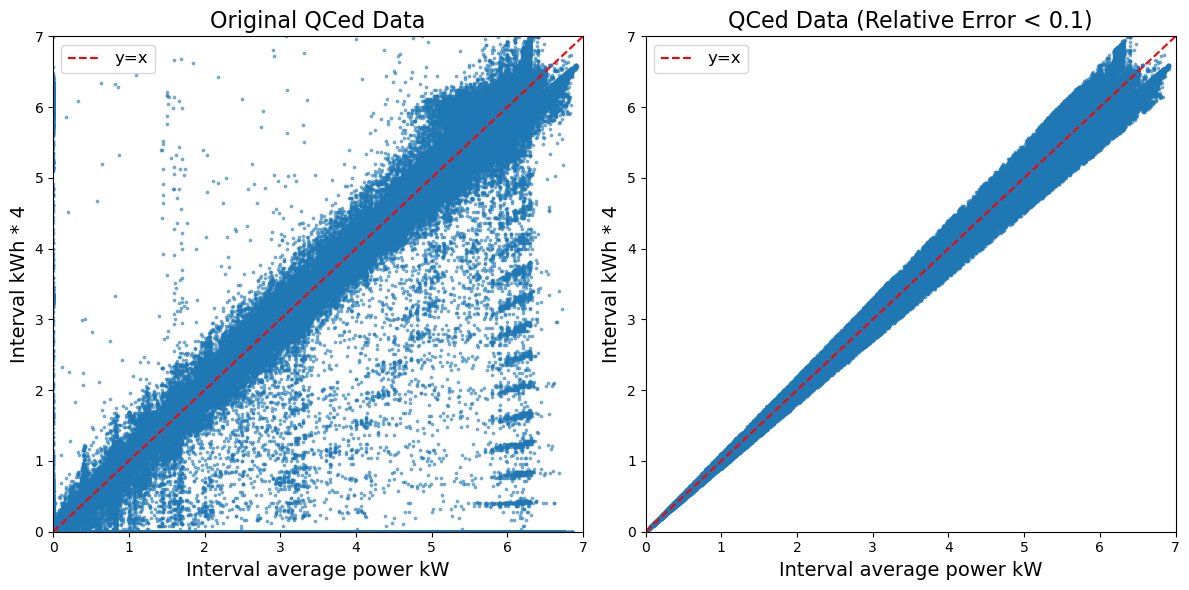

In [42]:
# interval kWh vs interval average power kW plots
power_hour_new = data_QC_clean['Interval average demand kW']
energy_hour_new = data_QC_clean['Interval kWh'] * 4

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axs[0].scatter(power_hour, energy_hour, alpha=0.5, s=3)
axs[0].plot([0, 7], [0, 7], color='red', linestyle='--', label='y=x')
axs[0].set_xlim(0, 7)
axs[0].set_ylim(0, 7)
axs[0].set_xlabel('Interval average power kW', fontsize=14)
axs[0].set_ylabel('Interval kWh * 4', fontsize=14)
axs[0].set_title('Original QCed Data', fontsize=16)
axs[0].legend(fontsize=12)

axs[1].scatter(power_hour_new, energy_hour_new, alpha=0.5, s=3)
axs[1].plot([0, 7], [0, 7], color='red', linestyle='--', label='y=x')
axs[1].set_xlim(0, 7)
axs[1].set_ylim(0, 7)
axs[1].set_xlabel('Interval average power kW', fontsize=14)
axs[1].set_ylabel('Interval kWh * 4', fontsize=14)
axs[1].set_title('QCed Data (Relative Error < 0.1)', fontsize=16)
axs[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig("QCed_AvgPower_vs_kWh_combined.png", dpi=300)
plt.show()




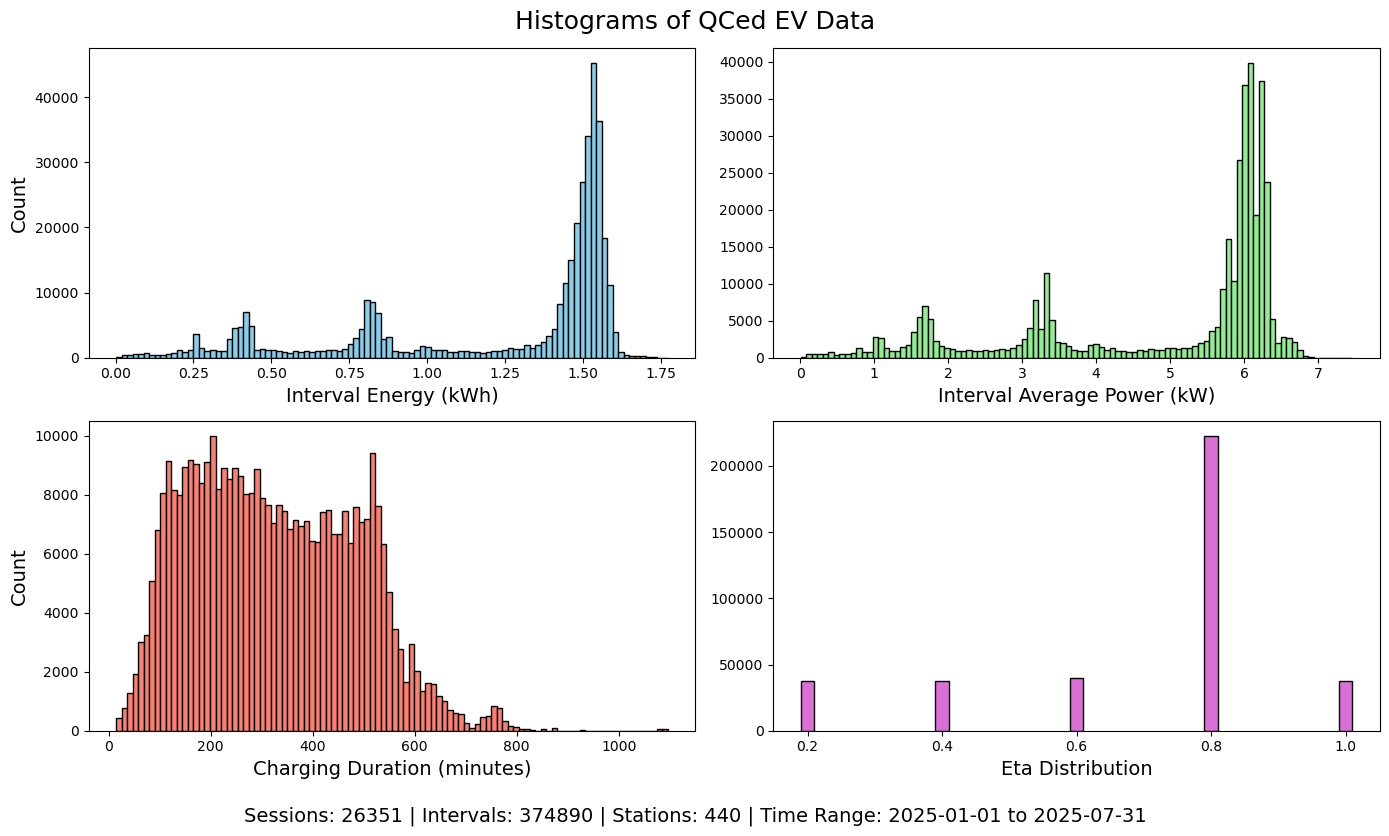

In [41]:
# Histograms for energy, power, duration, eta
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

step = np.diff(eta_choices).mean()  # assumes equal spacing
bin_edges = np.concatenate(([eta_choices[0] - step/2],
                            eta_choices + step/2))

axs[0, 0].set_xlabel('Interval Energy (kWh)', fontsize=14)
axs[0, 0].set_ylabel('Count', fontsize=14)
axs[0, 0].set_title('')
axs[0, 0].hist(data_QC_clean['Interval kWh'], bins=100, color='skyblue', edgecolor='black')

axs[0, 1].set_xlabel('Interval Average Power (kW)', fontsize=14)
# axs[0, 1].set_ylabel('Count', fontsize=14)
axs[0, 1].set_title('')
axs[0, 1].hist(data_QC_clean['Interval average demand kW'], bins=100, color='lightgreen', edgecolor='black')

axs[1, 0].set_xlabel('Charging Duration (minutes)', fontsize=14)
axs[1, 0].set_ylabel('Count', fontsize=14)
axs[1, 0].set_title('')
axs[1, 0].hist(data_QC_clean['Charging duration (minutes)'], bins=100, color='salmon', edgecolor='black')

axs[1, 1].set_xlabel('Eta Distribution', fontsize=14)
# axs[1, 1].set_ylabel('Count', fontsize=14)
axs[1, 1].set_title('')
axs[1, 1].hist(data_QC_clean['Eta'], bins=bin_edges, color='orchid', edgecolor='black', rwidth=0.1)



# other information
n_sessions = data_QC_clean['10-digit UID'].nunique()
n_intervals = len(data_QC_clean)
n_stations = data_QC_clean['Station Name'].nunique()
# Use datetime form for time range
start_dt = pd.to_datetime(TheDate_Start_str, format="%Y%m%d")
end_dt = pd.to_datetime(TheDate_End_str, format="%Y%m%d") - pd.Timedelta(days=1)
time_range = f"{start_dt.strftime('%Y-%m-%d')} to {end_dt.strftime('%Y-%m-%d')}"

fig.text(0.5, -0.04, f'Sessions: {n_sessions} | Intervals: {n_intervals} | Stations: {n_stations} | Time Range: {time_range}',
               fontsize=14, va='bottom', ha='center',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

fig.suptitle('Histograms of QCed EV Data', fontsize=18)
plt.tight_layout()
plt.savefig("QCed_EV_data_histograms.png", dpi=300)
plt.show()




Debugs

In [ ]:
# check old data if session start and end are on the same day
df_old = pd.read_csv("/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/2024_RO3.4/UCSD_AllSites_Merge_Eta_20210504_20230129_v3.csv")
df_old['Session start'] = pd.to_datetime(df_old['Session start'])
df_old['Session end'] = pd.to_datetime(df_old['Session end'])
df_old['Interval start'] = pd.to_datetime(df_old['Interval start'])
df_old['Interval end'] = pd.to_datetime(df_old['Interval end'])

# Check if 'Session start' and 'Session end' are on the same day for all rows
same_day = (df_old['Session start'].dt.date == df_old['Session end'].dt.date)
if same_day.all():
    print("All rows have 'Session start' and 'Session end' on the same day.")
else:
    print("Some rows have 'Session start' and 'Session end' on different days.")
    print(df_old[~same_day][['Session start', 'Session end']])


same_day_interval = (df_old['Interval start'].dt.date == df_old['Interval end'].dt.date)
if same_day_interval.all():
    print("All rows have 'Interval start' and 'Interval end' on the same day.")
else:
    print("Some rows have 'Interval start' and 'Interval end' on different days.")
    #print(df_old[~same_day_interval][['Interval start', 'Interval end']])
    
same_day_session_interval = (df_old['Session start'].dt.date == df_old['Interval start'].dt.date)
if same_day_session_interval.all():
    print("All rows have 'Session start' and 'Interval start' on the same day.")
else:
    print("Some rows have 'Session start' and 'Interval start' on different days.")
    print(df_old[~same_day_session_interval][['Session start', 'Interval start', 'Interval end', 'Session end']])
